In [3]:
# ============================================================
# 1. IMPORTS
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

from lightgbm import LGBMClassifier

RANDOM_STATE = 42
N_SPLITS = 5
TARGET_COL = "label"

TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SUB_PATH = "Sample.csv"

In [4]:
# ============================================================
# 2. LOAD DATA
# ============================================================
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print(train_df.head())

Train shape: (198000, 15)
Test shape : (102000, 14)
                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN    NaN       False   
4           0       0         0     0    10  NaN      NaN    NaN       False   

                                  

In [5]:
# ============================================================
# 3. BASIC EDA
# ============================================================
def basic_eda(df, target_col="label"):
    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False).head(20))

    if target_col in df.columns:
        print("\nTarget distribution:")
        print(df[target_col].value_counts())
        print("\nTarget ratio:")
        print(df[target_col].value_counts(normalize=True).sort_index())

basic_eda(train_df, TARGET_COL)


Missing values:
race            145423
religion        145423
gender          145423
comment              1
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
disability           0
label                0
dtype: int64

Target distribution:
label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Target ratio:
label
0    0.576631
1    0.080394
2    0.315354
3    0.027621
Name: proportion, dtype: float64


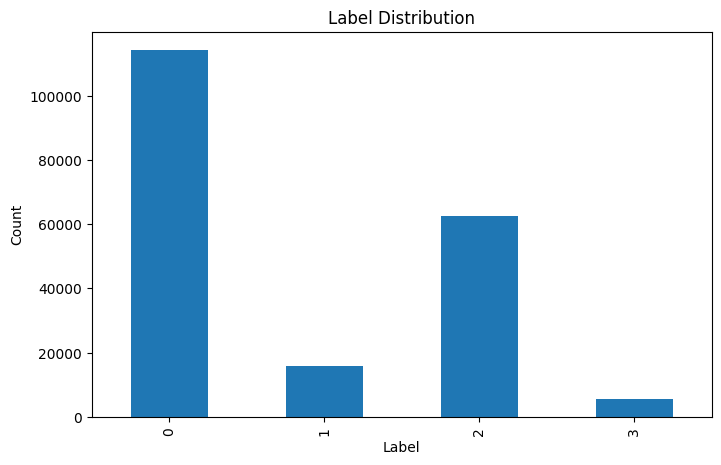

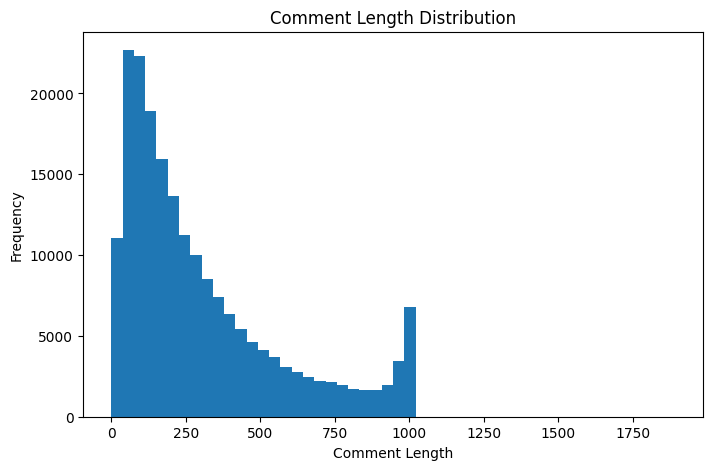

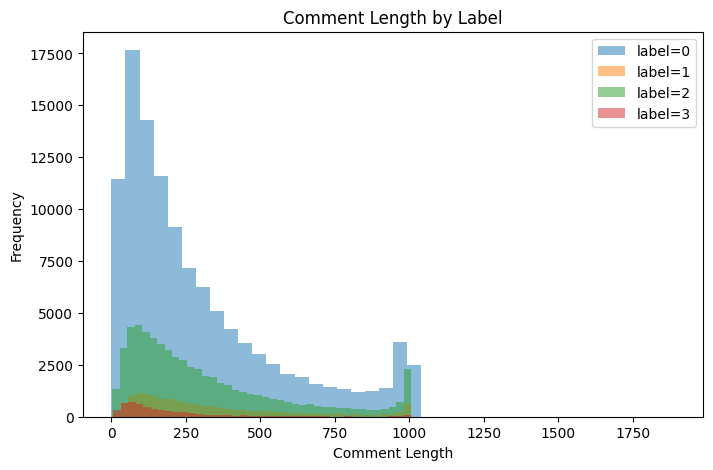

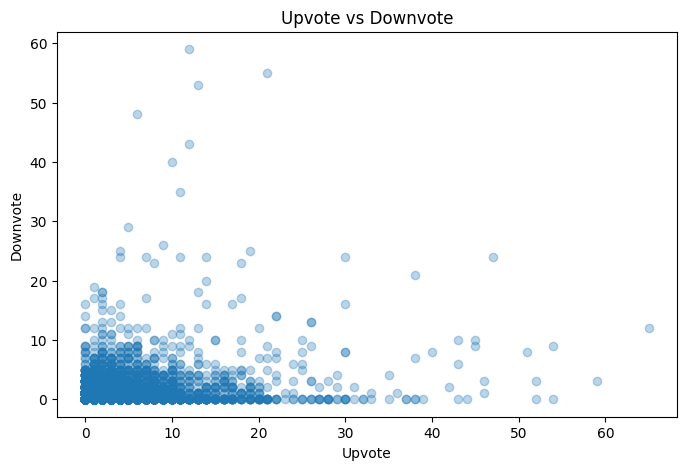

In [6]:
# ============================================================
# 4. VISUALIZATIONS
# ============================================================
def add_basic_text_stats(df):
    df = df.copy()
    df["comment"] = df["comment"].fillna("").astype(str)
    df["comment_len"] = df["comment"].str.len()
    df["word_count"] = df["comment"].str.split().str.len()
    df["char_per_word"] = df["comment_len"] / (df["word_count"].replace(0, 1))
    return df

eda_df = add_basic_text_stats(train_df)

# 4.1 Label distribution
plt.figure(figsize=(8, 5))
eda_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# 4.2 Comment length distribution
plt.figure(figsize=(8, 5))
plt.hist(eda_df["comment_len"], bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.show()

# 4.3 Comment length by label
plt.figure(figsize=(8, 5))
for label_value in sorted(eda_df[TARGET_COL].unique()):
    vals = eda_df.loc[eda_df[TARGET_COL] == label_value, "comment_len"]
    plt.hist(vals, bins=40, alpha=0.5, label=f"label={label_value}")
plt.title("Comment Length by Label")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 4.4 Upvote vs Downvote
plt.figure(figsize=(8, 5))
sample_plot = eda_df.sample(min(10000, len(eda_df)), random_state=RANDOM_STATE)
plt.scatter(sample_plot["upvote"], sample_plot["downvote"], alpha=0.3)
plt.title("Upvote vs Downvote")
plt.xlabel("Upvote")
plt.ylabel("Downvote")
plt.show()

In [7]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================
def clean_text(text):
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def add_engineered_features(df):
    df = df.copy()

    # ---------- text cleanup ----------
    df["comment"] = df["comment"].fillna("").astype(str).apply(clean_text)

    # ---------- categorical cleanup ----------
    for col in ["race", "religion", "gender"]:
        if col in df.columns:
            df[col] = df[col].fillna("missing").astype(str).str.lower().str.strip()

    if "disability" in df.columns:
        df["disability"] = df["disability"].fillna(False).astype(int)

    # ---------- datetime features ----------
    dt = pd.to_datetime(df["created_date"], utc=True, errors="coerce")
    df["year"] = dt.dt.year.fillna(-1).astype(int)
    df["month"] = dt.dt.month.fillna(-1).astype(int)
    df["day"] = dt.dt.day.fillna(-1).astype(int)
    df["dayofweek"] = dt.dt.dayofweek.fillna(-1).astype(int)
    df["hour"] = dt.dt.hour.fillna(-1).astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # ---------- text stats ----------
    df["comment_len"] = df["comment"].str.len()
    df["word_count"] = df["comment"].str.split().str.len()
    df["unique_word_count"] = df["comment"].apply(lambda x: len(set(x.lower().split())))
    df["unique_word_ratio"] = df["unique_word_count"] / df["word_count"].replace(0, 1)

    df["uppercase_count"] = df["comment"].str.count(r"[A-Z]")
    df["uppercase_ratio"] = df["uppercase_count"] / df["comment_len"].replace(0, 1)

    df["digit_count"] = df["comment"].str.count(r"\d")
    df["punct_count"] = df["comment"].str.count(r"[^\w\s]")
    df["exclamation_count"] = df["comment"].str.count(r"!")
    df["question_count"] = df["comment"].str.count(r"\?")
    df["emoji_like_count"] = (
        df["emoticon_1"].fillna(0).astype(int)
        + df["emoticon_2"].fillna(0).astype(int)
        + df["emoticon_3"].fillna(0).astype(int)
    )

    # ---------- voting features ----------
    df["upvote"] = df["upvote"].fillna(0)
    df["downvote"] = df["downvote"].fillna(0)
    df["net_votes"] = df["upvote"] - df["downvote"]
    df["total_votes"] = df["upvote"] + df["downvote"]
    df["vote_ratio"] = df["upvote"] / (df["total_votes"] + 1)

    # ---------- interaction features ----------
    df["if_1"] = df["if_1"].fillna(0)
    df["if_2"] = df["if_2"].fillna(0)
    df["if_sum"] = df["if_1"] + df["if_2"]
    df["if_diff"] = df["if_1"] - df["if_2"]

    # ---------- identity topic count ----------
    topic_cols = ["race", "religion", "gender"]
    topic_non_missing = []
    for col in topic_cols:
        topic_non_missing.append((df[col] != "missing").astype(int))
    df["identity_topic_count"] = np.sum(topic_non_missing, axis=0)

    # ---------- post frequency signal ----------
    # Often useful: comments under same post may share patterns
    post_counts = df["post_id"].value_counts()
    df["post_comment_count"] = df["post_id"].map(post_counts).fillna(1)

    return df

train_fe = add_engineered_features(train_df)
test_fe = add_engineered_features(test_df)

print(train_fe.shape, test_fe.shape)

(198000, 39) (102000, 38)


In [8]:
# ============================================================
# 6. FEATURE GROUPS
# ============================================================
TEXT_COL = "comment"

CAT_COLS = ["race", "religion", "gender"]

NUM_COLS = [
    "post_id",
    "emoticon_1",
    "emoticon_2",
    "emoticon_3",
    "upvote",
    "downvote",
    "if_1",
    "if_2",
    "disability",
    "year",
    "month",
    "day",
    "dayofweek",
    "hour",
    "is_weekend",
    "comment_len",
    "word_count",
    "unique_word_count",
    "unique_word_ratio",
    "uppercase_count",
    "uppercase_ratio",
    "digit_count",
    "punct_count",
    "exclamation_count",
    "question_count",
    "emoji_like_count",
    "net_votes",
    "total_votes",
    "vote_ratio",
    "if_sum",
    "if_diff",
    "identity_topic_count",
    "post_comment_count"
]

In [9]:
# ============================================================
# 7. TEXT + TABULAR VECTORIZATION
# ============================================================
class SparseFeatureBuilder:
    """
    Builds:
    - word tfidf
    - char tfidf
    - one-hot categorical
    - numeric sparse matrix
    """
    def __init__(
        self,
        word_max_features=80000,
        char_max_features=50000,
        use_char=True
    ):
        self.word_vectorizer = TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.98,
            sublinear_tf=True,
            max_features=word_max_features
        )
        self.use_char = use_char
        self.char_vectorizer = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=3,
            sublinear_tf=True,
            max_features=char_max_features
        )
        self.ohe = OneHotEncoder(handle_unknown="ignore")
        self.num_imputer = SimpleImputer(strategy="median")
        self.num_scaler = StandardScaler(with_mean=False)

    def fit(self, df):
        self.word_vectorizer.fit(df[TEXT_COL])
        if self.use_char:
            self.char_vectorizer.fit(df[TEXT_COL])

        self.ohe.fit(df[CAT_COLS])

        num_array = self.num_imputer.fit_transform(df[NUM_COLS])
        self.num_scaler.fit(sparse.csr_matrix(num_array))
        return self

    def transform(self, df):
        X_word = self.word_vectorizer.transform(df[TEXT_COL])

        blocks = [X_word]

        if self.use_char:
            X_char = self.char_vectorizer.transform(df[TEXT_COL])
            blocks.append(X_char)

        X_cat = self.ohe.transform(df[CAT_COLS])
        blocks.append(X_cat)

        num_array = self.num_imputer.transform(df[NUM_COLS])
        X_num = sparse.csr_matrix(num_array)
        X_num = self.num_scaler.transform(X_num)
        blocks.append(X_num)

        return sparse.hstack(blocks).tocsr()

In [10]:
# ============================================================
# 8. CROSS-VALIDATION UTILITY
# ============================================================
def evaluate_model_cv(
    model,
    train_df,
    feature_builder,
    target_col="label",
    n_splits=5,
    model_name="model",
    use_predict_proba=True
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    oof_preds = np.zeros(len(train_df), dtype=int)
    oof_proba = None

    all_acc = []
    all_f1 = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, train_df[target_col]), 1):
        tr_df = train_df.iloc[tr_idx].copy()
        va_df = train_df.iloc[va_idx].copy()

        fb = feature_builder
        fb.fit(tr_df)

        X_tr = fb.transform(tr_df)
        X_va = fb.transform(va_df)

        y_tr = tr_df[target_col].values
        y_va = va_df[target_col].values

        model.fit(X_tr, y_tr)

        preds = model.predict(X_va)
        oof_preds[va_idx] = preds

        acc = accuracy_score(y_va, preds)
        f1 = f1_score(y_va, preds, average="macro")
        all_acc.append(acc)
        all_f1.append(f1)

        print(f"{model_name} | Fold {fold} | Accuracy={acc:.5f} | MacroF1={f1:.5f}")

    print(f"\n{model_name} CV Accuracy : {np.mean(all_acc):.5f} +/- {np.std(all_acc):.5f}")
    print(f"{model_name} CV Macro F1: {np.mean(all_f1):.5f} +/- {np.std(all_f1):.5f}")

    return {
        "model_name": model_name,
        "oof_preds": oof_preds,
        "cv_accuracy_mean": np.mean(all_acc),
        "cv_accuracy_std": np.std(all_acc),
        "cv_f1_mean": np.mean(all_f1),
        "cv_f1_std": np.std(all_f1),
    }

In [11]:
# ============================================================
# 9. BASELINE STRONG SPARSE MODELS
# ============================================================

# Feature builder for sparse models
sparse_builder = SparseFeatureBuilder(
    word_max_features=60000,
    char_max_features=40000,
    use_char=True
)

# 9.1 Logistic Regression
log_reg = LogisticRegression(
    C=4.0,
    max_iter=2000,
    class_weight="balanced",
    solver="saga",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# 9.2 Linear SVM with calibration-friendly wrapper later
linear_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# 9.3 SGD classifier (fast linear model)
sgd_model = SGDClassifier(
    loss="log_loss",
    alpha=1e-5,
    penalty="l2",
    max_iter=3000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 9.4 Multinomial NB (text-heavy baseline)
mnb_model = MultinomialNB(alpha=0.05)

# Example:
# logreg_result = evaluate_model_cv(log_reg, train_fe, sparse_builder, model_name="LogReg")
# svm_result    = evaluate_model_cv(linear_svm, train_fe, sparse_builder, model_name="LinearSVM")
# sgd_result    = evaluate_model_cv(sgd_model, train_fe, sparse_builder, model_name="SGD")
# mnb_result    = evaluate_model_cv(mnb_model, train_fe, sparse_builder, model_name="MultinomialNB")

In [13]:
# ============================================================
# 10. HYPERPARAMETER TUNING FOR LINEAR MODELS
# ============================================================
# Use a single validation split for speed during tuning,
# then run full CV with the best params.

# tr_df, va_df = train_test_split(
#     train_fe,
#     test_size=0.2,
#     stratify=train_fe[TARGET_COL],
#     random_state=RANDOM_STATE
# )

# builder_tune = SparseFeatureBuilder(
#     word_max_features=50000,
#     char_max_features=30000,
#     use_char=True
# )
# builder_tune.fit(tr_df)

# X_tr_tune = builder_tune.transform(tr_df)
# X_va_tune = builder_tune.transform(va_df)
# y_tr_tune = tr_df[TARGET_COL].values
# y_va_tune = va_df[TARGET_COL].values

# # ---------- Logistic Regression tuning ----------
# logreg_candidates = [
#     {"C": 1.0, "class_weight": None},
#     {"C": 2.0, "class_weight": "balanced"},
#     {"C": 4.0, "class_weight": "balanced"},
#     {"C": 6.0, "class_weight": "balanced"},
#     {"C": 8.0, "class_weight": None},
# ]

# best_logreg = None
# best_logreg_score = -1

# for params in logreg_candidates:
#     model = LogisticRegression(
#         C=params["C"],
#         class_weight=params["class_weight"],
#         solver="saga",
#         max_iter=2000,
#         n_jobs=-1,
#         random_state=RANDOM_STATE
#     )
#     model.fit(X_tr_tune, y_tr_tune)
#     preds = model.predict(X_va_tune)
#     acc = accuracy_score(y_va_tune, preds)
#     f1 = f1_score(y_va_tune, preds, average="macro")
#     print("LogReg params:", params, "| Acc:", round(acc, 5), "| F1:", round(f1, 5))

#     if acc > best_logreg_score:
#         best_logreg_score = acc
#         best_logreg = model

# print("\nBest LogReg validation accuracy:", best_logreg_score)

# ---------- LinearSVM tuning ----------
svm_candidates = [
    {"C": 0.5},
    {"C": 1.0},
    {"C": 1.5},
    {"C": 2.0},
]

best_svm = None
best_svm_score = -1

for params in svm_candidates:
    model = LinearSVC(
        C=params["C"],
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    model.fit(X_tr_tune, y_tr_tune)
    preds = model.predict(X_va_tune)
    acc = accuracy_score(y_va_tune, preds)
    f1 = f1_score(y_va_tune, preds, average="macro")
    print("LinearSVM params:", params, "| Acc:", round(acc, 5), "| F1:", round(f1, 5))

    if acc > best_svm_score:
        best_svm_score = acc
        best_svm = model

print("\nBest LinearSVM validation accuracy:", best_svm_score)

LinearSVM params: {'C': 0.5} | Acc: 0.65202 | F1: 0.55351
LinearSVM params: {'C': 1.0} | Acc: 0.65005 | F1: 0.55045
LinearSVM params: {'C': 1.5} | Acc: 0.65899 | F1: 0.56633
LinearSVM params: {'C': 2.0} | Acc: 0.64725 | F1: 0.54574

Best LinearSVM validation accuracy: 0.658989898989899


In [14]:
# ============================================================
# 11. LIGHTGBM WITH SVD FEATURES
# ============================================================
# LightGBM usually works better on dense compressed text than raw sparse TF-IDF.

class DenseFeatureBuilder:
    def __init__(self, word_max_features=50000, char_max_features=25000, n_svd=300):
        self.word_vectorizer = TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.98,
            sublinear_tf=True,
            max_features=word_max_features
        )
        self.char_vectorizer = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=3,
            sublinear_tf=True,
            max_features=char_max_features
        )
        self.ohe = OneHotEncoder(handle_unknown="ignore")
        self.num_imputer = SimpleImputer(strategy="median")
        self.svd = TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)

    def fit(self, df):
        X_word = self.word_vectorizer.fit_transform(df[TEXT_COL])
        X_char = self.char_vectorizer.fit_transform(df[TEXT_COL])
        X_cat = self.ohe.fit_transform(df[CAT_COLS])

        X_text_sparse = sparse.hstack([X_word, X_char, X_cat]).tocsr()
        self.svd.fit(X_text_sparse)
        self.num_imputer.fit(df[NUM_COLS])
        return self

    def transform(self, df):
        X_word = self.word_vectorizer.transform(df[TEXT_COL])
        X_char = self.char_vectorizer.transform(df[TEXT_COL])
        X_cat = self.ohe.transform(df[CAT_COLS])

        X_text_sparse = sparse.hstack([X_word, X_char, X_cat]).tocsr()
        X_text_dense = self.svd.transform(X_text_sparse)

        X_num = self.num_imputer.transform(df[NUM_COLS])

        return np.hstack([X_text_dense, X_num])

def evaluate_dense_model_cv(model, train_df, feature_builder, target_col="label", n_splits=5, model_name="DenseModel"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    all_acc = []
    all_f1 = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, train_df[target_col]), 1):
        tr_df = train_df.iloc[tr_idx].copy()
        va_df = train_df.iloc[va_idx].copy()

        fb = feature_builder
        fb.fit(tr_df)

        X_tr = fb.transform(tr_df)
        X_va = fb.transform(va_df)
        y_tr = tr_df[target_col].values
        y_va = va_df[target_col].values

        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)

        acc = accuracy_score(y_va, preds)
        f1 = f1_score(y_va, preds, average="macro")
        all_acc.append(acc)
        all_f1.append(f1)

        print(f"{model_name} | Fold {fold} | Accuracy={acc:.5f} | MacroF1={f1:.5f}")

    print(f"\n{model_name} CV Accuracy : {np.mean(all_acc):.5f} +/- {np.std(all_acc):.5f}")
    print(f"{model_name} CV Macro F1: {np.mean(all_f1):.5f} +/- {np.std(all_f1):.5f}")

dense_builder = DenseFeatureBuilder(
    word_max_features=40000,
    char_max_features=20000,
    n_svd=300
)

lgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=600,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=0.5,
    random_state=RANDOM_STATE
)

# Example:
# lgbm_result = evaluate_dense_model_cv(
#     lgbm_model,
#     train_fe,
#     dense_builder,
#     model_name="LightGBM_SVD"
# )

In [15]:
# ============================================================
# 12. LIGHTGBM HYPERPARAMETER TUNING
# ============================================================
tr_df_lgb, va_df_lgb = train_test_split(
    train_fe,
    test_size=0.2,
    stratify=train_fe[TARGET_COL],
    random_state=RANDOM_STATE
)

dense_builder_tune = DenseFeatureBuilder(
    word_max_features=30000,
    char_max_features=15000,
    n_svd=250
)
dense_builder_tune.fit(tr_df_lgb)

X_tr_lgb = dense_builder_tune.transform(tr_df_lgb)
X_va_lgb = dense_builder_tune.transform(va_df_lgb)
y_tr_lgb = tr_df_lgb[TARGET_COL].values
y_va_lgb = va_df_lgb[TARGET_COL].values

lgbm_candidates = [
    {"num_leaves": 31, "learning_rate": 0.05, "n_estimators": 400},
    {"num_leaves": 63, "learning_rate": 0.05, "n_estimators": 500},
    {"num_leaves": 63, "learning_rate": 0.03, "n_estimators": 700},
    {"num_leaves": 127, "learning_rate": 0.03, "n_estimators": 700},
]

best_lgbm = None
best_lgbm_score = -1

for params in lgbm_candidates:
    model = LGBMClassifier(
        objective="multiclass",
        num_class=4,
        subsample=0.85,
        colsample_bytree=0.8,
        min_child_samples=30,
        reg_alpha=0.2,
        reg_lambda=0.5,
        random_state=RANDOM_STATE,
        **params
    )
    model.fit(X_tr_lgb, y_tr_lgb)
    preds = model.predict(X_va_lgb)
    acc = accuracy_score(y_va_lgb, preds)
    f1 = f1_score(y_va_lgb, preds, average="macro")
    print("LGBM params:", params, "| Acc:", round(acc, 5), "| F1:", round(f1, 5))

    if acc > best_lgbm_score:
        best_lgbm_score = acc
        best_lgbm = model

print("\nBest LightGBM validation accuracy:", best_lgbm_score)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.182014 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 66303
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 283
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
LGBM params: {'num_leaves': 31, 'learning_rate': 0.05, 'n_estimators': 400} | Acc: 0.89402 | F1: 0.73385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.671797 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 66303
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 283
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from sco

In [16]:
# ============================================================
# 13. FINAL TRAINING HELPERS
# ============================================================
def fit_sparse_model_and_predict(
    train_df,
    test_df,
    model,
    builder
):
    builder.fit(train_df)
    X_train = builder.transform(train_df)
    X_test = builder.transform(test_df)
    y_train = train_df[TARGET_COL].values

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
    else:
        proba = None

    return preds, proba, model, builder

def fit_dense_model_and_predict(
    train_df,
    test_df,
    model,
    builder
):
    builder.fit(train_df)
    X_train = builder.transform(train_df)
    X_test = builder.transform(test_df)
    y_train = train_df[TARGET_COL].values

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
    else:
        proba = None

    return preds, proba, model, builder

In [17]:
# ============================================================
# 14. CALIBRATED SVM FOR ENSEMBLE
# ============================================================
# SVM gives strong class predictions, but for soft voting we want probabilities.
# CalibratedClassifierCV wraps LinearSVC.

calibrated_svm = CalibratedClassifierCV(
    estimator=LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
    method="sigmoid",
    cv=3
)

In [18]:
# ============================================================
# 15. TRAIN FINAL INDIVIDUAL MODELS
# ============================================================

# 15.1 Logistic Regression
final_sparse_builder_lr = SparseFeatureBuilder(
    word_max_features=70000,
    char_max_features=40000,
    use_char=True
)
final_logreg = LogisticRegression(
    C=4.0,
    max_iter=2000,
    class_weight="balanced",
    solver="saga",
    n_jobs=-1,
    random_state=RANDOM_STATE
)
lr_test_preds, lr_test_proba, _, _ = fit_sparse_model_and_predict(
    train_fe,
    test_fe,
    final_logreg,
    final_sparse_builder_lr
)

# 15.2 Calibrated Linear SVM
final_sparse_builder_svm = SparseFeatureBuilder(
    word_max_features=70000,
    char_max_features=40000,
    use_char=True
)
svm_test_preds, svm_test_proba, _, _ = fit_sparse_model_and_predict(
    train_fe,
    test_fe,
    calibrated_svm,
    final_sparse_builder_svm
)

# 15.3 LightGBM dense model
final_dense_builder = DenseFeatureBuilder(
    word_max_features=40000,
    char_max_features=20000,
    n_svd=300
)
final_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=600,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=0.5,
    random_state=RANDOM_STATE
)
lgbm_test_preds, lgbm_test_proba, _, _ = fit_dense_model_and_predict(
    train_fe,
    test_fe,
    final_lgbm,
    final_dense_builder
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.259637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 79129
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 333
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171


In [19]:
# ============================================================
# 16. SOFT VOTING ENSEMBLE
# ============================================================
# Weighted average of probabilities
# Usually stronger than using any single model alone.

ensemble_proba = (
    0.35 * lr_test_proba +
    0.35 * svm_test_proba +
    0.30 * lgbm_test_proba
)

ensemble_test_preds = ensemble_proba.argmax(axis=1)

print("Ensemble prediction shape:", ensemble_test_preds.shape)

Ensemble prediction shape: (102000,)


In [20]:
# ============================================================
# 17. CREATE SUBMISSION
# ============================================================
submission = pd.read_csv(SUB_PATH)

# Adjust this if sample submission uses a different column name
# Most likely it expects a column named "label"
submission["label"] = ensemble_test_preds

print(submission.head())
submission.to_csv("submission_ensemble.csv", index=False)
print("Saved: submission_ensemble.csv")

   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
Saved: submission_ensemble.csv


In [ ]:
# ============================================================
# 18. OPTIONAL: VALIDATION ENSEMBLE CHECK
# ============================================================
# Run this on a holdout split first before full training.
# This helps verify that your ensemble is actually beating single models.

tr_df_hold, va_df_hold = train_test_split(
    train_fe,
    test_size=0.2,
    stratify=train_fe[TARGET_COL],
    random_state=RANDOM_STATE
)

# ----- LR -----
fb_lr = SparseFeatureBuilder(word_max_features=50000, char_max_features=30000, use_char=True)
fb_lr.fit(tr_df_hold)
X_tr_lr = fb_lr.transform(tr_df_hold)
X_va_lr = fb_lr.transform(va_df_hold)

hold_lr = LogisticRegression(
    C=4.0,
    max_iter=2000,
    class_weight="balanced",
    solver="saga",
    n_jobs=-1,
    random_state=RANDOM_STATE
)
hold_lr.fit(X_tr_lr, tr_df_hold[TARGET_COL].values)
lr_va_proba = hold_lr.predict_proba(X_va_lr)
lr_va_pred = lr_va_proba.argmax(axis=1)

# ----- SVM -----
fb_svm = SparseFeatureBuilder(word_max_features=50000, char_max_features=30000, use_char=True)
fb_svm.fit(tr_df_hold)
X_tr_svm = fb_svm.transform(tr_df_hold)
X_va_svm = fb_svm.transform(va_df_hold)

hold_svm = CalibratedClassifierCV(
    estimator=LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
    method="sigmoid",
    cv=3
)
hold_svm.fit(X_tr_svm, tr_df_hold[TARGET_COL].values)
svm_va_proba = hold_svm.predict_proba(X_va_svm)
svm_va_pred = svm_va_proba.argmax(axis=1)

# ----- LGBM -----
fb_lgb = DenseFeatureBuilder(word_max_features=30000, char_max_features=15000, n_svd=250)
fb_lgb.fit(tr_df_hold)
X_tr_lgb = fb_lgb.transform(tr_df_hold)
X_va_lgb = fb_lgb.transform(va_df_hold)

hold_lgb = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE
)
hold_lgb.fit(X_tr_lgb, tr_df_hold[TARGET_COL].values)
lgb_va_proba = hold_lgb.predict_proba(X_va_lgb)
lgb_va_pred = lgb_va_proba.argmax(axis=1)

# ----- Ensemble -----
ensemble_va_proba = (
    0.35 * lr_va_proba +
    0.35 * svm_va_proba +
    0.30 * lgb_va_proba
)
ensemble_va_pred = ensemble_va_proba.argmax(axis=1)

y_true = va_df_hold[TARGET_COL].values

print("LogReg Accuracy   :", accuracy_score(y_true, lr_va_pred))
print("SVM Accuracy      :", accuracy_score(y_true, svm_va_pred))
print("LGBM Accuracy     :", accuracy_score(y_true, lgb_va_pred))
print("Ensemble Accuracy :", accuracy_score(y_true, ensemble_va_pred))

print("\nMacro F1 scores")
print("LogReg MacroF1   :", f1_score(y_true, lr_va_pred, average="macro"))
print("SVM MacroF1      :", f1_score(y_true, svm_va_pred, average="macro"))
print("LGBM MacroF1     :", f1_score(y_true, lgb_va_pred, average="macro"))
print("Ensemble MacroF1 :", f1_score(y_true, ensemble_va_pred, average="macro"))

In [ ]:
# ============================================================
# 19. CONFUSION MATRIX VISUALIZATION
# ============================================================
cm = confusion_matrix(y_true, ensemble_va_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, ensemble_va_pred))

In [ ]:
# ============================================================
# 20. EXTRA MODELS YOU CAN TRY
# ============================================================

# 20.1 Extra-fast linear model
extra_sgd = SGDClassifier(
    loss="modified_huber",
    alpha=1e-5,
    max_iter=3000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 20.2 Another sparse baseline
extra_mnb = MultinomialNB(alpha=0.02)

# 20.3 Another LightGBM setting
extra_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE
)

# You can evaluate them using the same helper functions.